# 📖 Notebook 01 — EDA & Data Exploration

> This notebook focuses on exploring the CoNLL-2003 dataset, understanding the IOB tagging scheme, analyzing label distributions, sentence lengths, and building the necessary vocabularies for our Named Entity Recognition (NER) models.

| Field | Details |
|---|---|
| Notebook | 01_EDA_and_Data_Exploration |
| Purpose | Explore the CoNLL-2003 dataset and visualize IOB tagging |
| Input | CoNLL-2003 via HuggingFace Datasets |
| Output | `../data/vocab.pkl`, `../data/char_vocab.pkl`, `../figures/label_dist.png`, `../figures/sentence_len_dist.png` |
| Runtime | ~2 min (CPU) |
| Next Notebook | 02_Preprocessing_and_Embeddings |


### 📦 1. Setup & Imports

In this section, we install and import the necessary libraries. We use `datasets` from HuggingFace to load the CoNLL-2003 dataset, and standard data science libraries like `pandas`, `matplotlib`, and `seaborn` for data manipulation and visualization.


In [17]:
!pip install -q datasets evaluate gradio
!pip install -q pytorch-crf --no-build-isolation

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')

# Ensure output directories exist
os.makedirs('../data', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


### 🗂️ 2. Dataset Loading

We load the CoNLL-2003 dataset from HuggingFace. This dataset is a standard benchmark for Named Entity Recognition. It contains four types of named entities:
- **PER**: Person
- **LOC**: Location
- **ORG**: Organization
- **MISC**: Miscellaneous (e.g., nationalities, religions, events)

The dataset is pre-split into `train`, `validation`, and `test` sets. The `train` set contains 14,041 sentences.


In [18]:
# Load CoNLL-2003 dataset (Using Parquet-compatible mirror for Kaggle compatibility)
dataset = load_dataset("lhoestq/conll2003")

print("Dataset Info:")
print(dataset)

print("\nFirst 3 Examples:")
for i in range(3):
    tokens = dataset['train'][i]['tokens']
    ner_tags = dataset['train'][i]['ner_tags']
    print(f"Example {i+1}:")
    print(f"Tokens: {tokens}")
    print(f"Tags:   {ner_tags}")
    print("-" * 50)

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Dataset Info:
DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

First 3 Examples:
Example 1:
Tokens: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Tags:   [3, 0, 7, 0, 0, 0, 7, 0, 0]
--------------------------------------------------
Example 2:
Tokens: ['Peter', 'Blackburn']
Tags:   [1, 2]
--------------------------------------------------
Example 3:
Tokens: ['BRUSSELS', '1996-08-22']
Tags:   [5, 0]
--------------------------------------------------


### 🏷️ 3. IOB Tagging Scheme Explained

The dataset uses the **IOB** (Inside, Outside, Beginning) tagging scheme. It is crucial for NER because named entities often span multiple tokens (e.g., "New York City").

- **B- (Beginning):** Indicates the first token of a named entity.
- **I- (Inside):** Indicates subsequent tokens of the same named entity.
- **O (Outside):** Indicates a token that does not belong to any named entity.

**Example:**
```
Token:  London   is   a   city   in   New      York     City
Tag:    B-LOC    O    O   O      O    B-LOC    I-LOC    I-LOC
```

Let's extract the actual tag names and print their corresponding indices.


In [22]:
# Fixed standard CoNLL-2003 tag names mapping
tag_names = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

print("Tag Index to Name Mapping:")
for idx, tag in enumerate(tag_names):
    print(f"{idx}: {tag}")

Tag Index to Name Mapping:
0: O
1: B-PER
2: I-PER
3: B-ORG
4: I-ORG
5: B-LOC
6: I-LOC
7: B-MISC
8: I-MISC


### 📊 4. Entity Distribution Analysis

In NER tasks, the 'O' (Outside) tag heavily dominates the dataset, leading to severe class imbalance. We will count the occurrences of all entity tags across the splits and visualize the distribution (excluding 'O' for better clarity).


Tag Counts per Split:


,B-ORG,O,B-MISC,B-PER,I-PER,B-LOC,I-ORG,I-MISC,I-LOC
Train,6321,169578,3438,6600,4528,7140,3704,1155,1157
Validation,1341,42759,922,1842,1307,1837,751,346,257
Test,1661,38323,702,1617,1156,1668,835,216,257


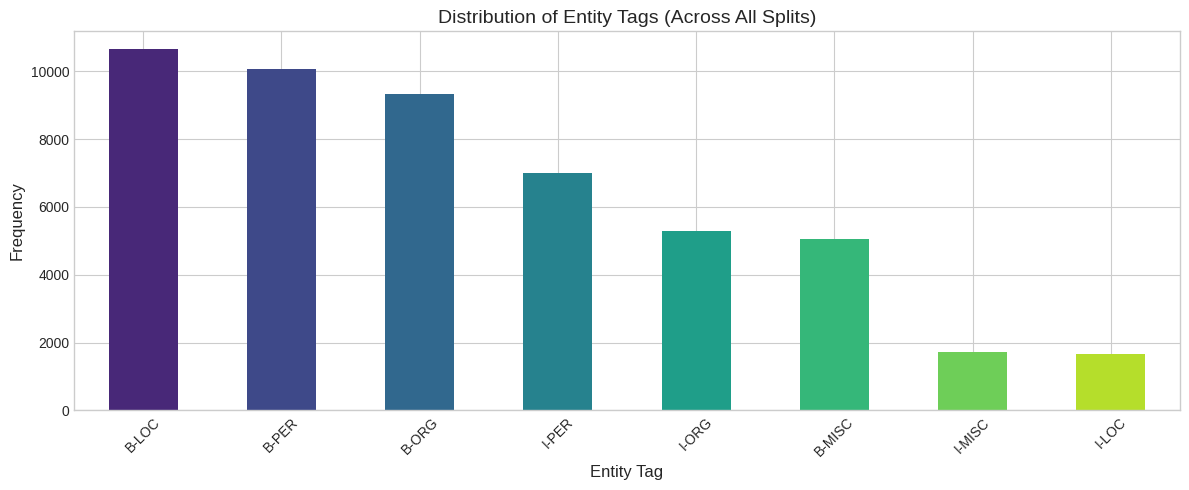

In [23]:
def get_tag_counts(split):
    all_tags = [tag_names[tag_idx] for seq in dataset[split]['ner_tags'] for tag_idx in seq]
    return Counter(all_tags)

train_counts = get_tag_counts('train')
val_counts = get_tag_counts('validation')
test_counts = get_tag_counts('test')

# Create a DataFrame for counts
df_counts = pd.DataFrame([train_counts, val_counts, test_counts], index=['Train', 'Validation', 'Test']).fillna(0).astype(int)
print("Tag Counts per Split:")
display(df_counts)

# Plotting the distribution of named entity tags (ignoring 'O' tag)
df_entities = df_counts.drop(columns=['O'])
df_entities.sum(axis=0).sort_values(ascending=False).plot(kind='bar', color=sns.color_palette("viridis", len(df_entities.columns)), figsize=(12, 5))
plt.title("Distribution of Entity Tags (Across All Splits)", fontsize=14)
plt.xlabel("Entity Tag", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/label_dist.png', dpi=300)
plt.show()

### 📏 5. Sentence Length Analysis

Understanding the distribution of sentence lengths is important for deciding on the sequence padding length during preprocessing. Sequences that are too long might consume too much memory, while those that are heavily padded might slow down training unnecessarily.


Mean sentence length: 14.50
Max sentence length: 113
95th percentile length: 37


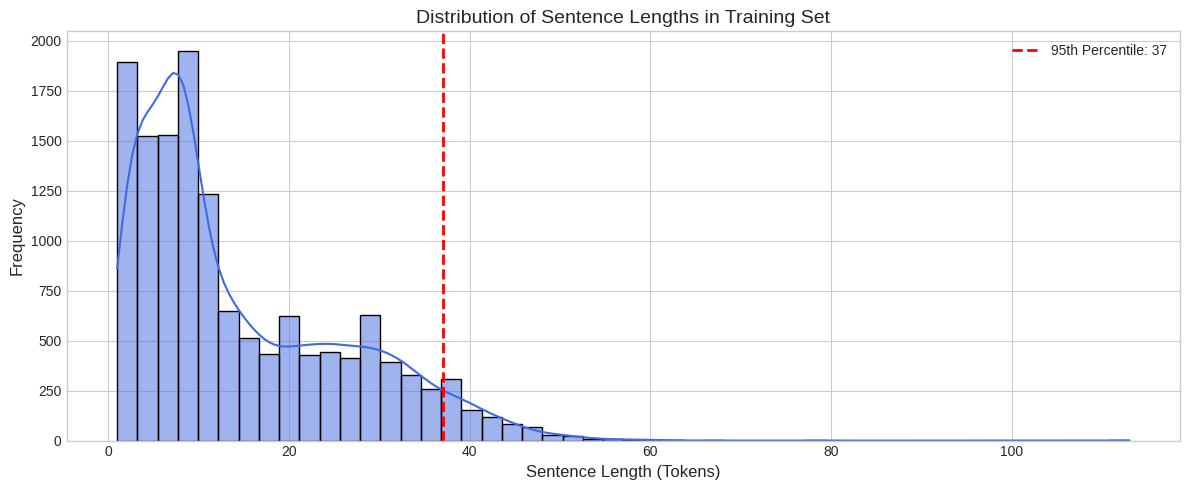

In [24]:
# Compute sentence lengths
train_lengths = [len(seq) for seq in dataset['train']['tokens']]

# Statistics
mean_len = np.mean(train_lengths)
max_len = np.max(train_lengths)
p95_len = np.percentile(train_lengths, 95)

print(f"Mean sentence length: {mean_len:.2f}")
print(f"Max sentence length: {max_len}")
print(f"95th percentile length: {p95_len:.0f}")

# Plotting
plt.figure(figsize=(12, 5))
sns.histplot(train_lengths, bins=50, kde=True, color='royalblue')
plt.axvline(p95_len, color='red', linestyle='dashed', linewidth=2, label=f'95th Percentile: {p95_len:.0f}')
plt.title('Distribution of Sentence Lengths in Training Set', fontsize=14)
plt.xlabel('Sentence Length (Tokens)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/sentence_len_dist.png', dpi=300)
plt.show()

### 🔠 6. Vocabulary Analysis

To convert words and characters into numerical inputs for our models, we need to build vocabularies. We will create a word-level vocabulary (filtering out infrequent words to handle Out-Of-Vocabulary (OOV) cases naturally with an `<UNK>` token) and a character-level vocabulary.


In [27]:
import os
import pickle

# Build word and character vocabularies
word_counter = Counter(word for seq in dataset['train']['tokens'] for word in seq)
char_counter = Counter(char for seq in dataset['train']['tokens'] for word in seq for char in word)

min_freq = 2

# Special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Word Vocab
word_vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, count in word_counter.items():
    if count >= min_freq:
        word_vocab[word] = len(word_vocab)

# Char Vocab (include all characters found)
char_vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for char in char_counter.keys():
    char_vocab[char] = len(char_vocab)

print(f"Word vocabulary size: {len(word_vocab)}")
print(f"Character vocabulary size: {len(char_vocab)}")
print("\nTop 20 most common words:")
print(word_counter.most_common(20))

# Ensure working data directory exists
os.makedirs('/kaggle/working/data', exist_ok=True)

# Save vocabularies to explicit Kaggle working path
with open('/kaggle/working/data/vocab.pkl', 'wb') as f:
    pickle.dump(word_vocab, f)

with open('/kaggle/working/data/char_vocab.pkl', 'wb') as f:
    pickle.dump(char_vocab, f)

print("\n✅ Vocabularies saved successfully to /kaggle/working/data/")

Word vocabulary size: 11984
Character vocabulary size: 86

Top 20 most common words:
[('.', 7374), (',', 7290), ('the', 7243), ('of', 3751), ('in', 3398), ('to', 3382), ('a', 2994), ('(', 2861), (')', 2861), ('and', 2838), ('"', 2178), ('on', 2040), ('said', 1846), ("'s", 1536), ('for', 1421), ('1', 1421), ('-', 1243), ('The', 1127), ('was', 1095), ('2', 973)]

✅ Vocabularies saved successfully to /kaggle/working/data/


### ✅ 7. Notebook Summary

**What was accomplished:**
- 📥 Loaded the CoNLL-2003 dataset and explored its structure.
- 🧠 Explained and visualized the IOB tagging scheme.
- 📊 Analyzed the class imbalance of entity tags.
- 📏 Analyzed sentence lengths to inform padding decisions (95th percentile length identified).
- 🔠 Built and saved word (min_freq=2) and character vocabularies for downstream modeling.

**Saved Files:**
- 🖼️ `../figures/label_dist.png`
- 🖼️ `../figures/sentence_len_dist.png`
- 💾 `../data/vocab.pkl`
- 💾 `../data/char_vocab.pkl`

**Next Step:**
→ Proceed to `02_Preprocessing_and_Embeddings.ipynb` for dataset tokenization, padding, and preparing GloVe embeddings.
